# Pre test

In [59]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from PIL import Image
import torch

In [60]:
# Загрузка модели и процессора
model_id = "IDEA-Research/grounding-dino-base"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(device)

In [61]:
# Загрузка изображения
image = Image.open("../data/fridge.jpg")

In [62]:
# Тексты объектов, которые хотим найти
texts = [["an apple.", "a bottle.", "milk.", "a banana.", "cheese.", "an egg.", "an orange.", "yogurt.", "bread.", "a cucumber.", "a carrot.", "a potato.", "an onion.", "a tomato.", "lettuce.", "a pepper.", "a broccoli.", "a cabbage."]]
text = " ".join(texts[0])  # Преобразуем список в строку

# Предобработка
inputs = processor(text=text, images=image, return_tensors="pt").to(device)

In [63]:
# Предсказание
with torch.no_grad():
    outputs = model(**inputs)

In [64]:
# Постобработка (превращение логитов в боксы и лейблы)
results = processor.post_process_grounded_object_detection(outputs, threshold=0.2, target_sizes=[image.size])[0]

In [65]:
# Пример вывода
for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
    print(f"Object: {label}, Score: {score:.2f}, Box: {box.tolist()}")

Object: lettuce, Score: 0.50, Box: [842.1240844726562, 1038.79931640625, 1317.5712890625, 1422.7525634765625]
Object: a bottle, Score: 0.43, Box: [484.1686096191406, 541.7108154296875, 614.4616088867188, 904.1098022460938]
Object: an onion, Score: 0.37, Box: [67.47489166259766, 1161.5032958984375, 362.3655700683594, 1413.237060546875]
Object: a bottle, Score: 0.31, Box: [341.1814880371094, 594.6073608398438, 431.5564880371094, 725.3013916015625]
Object: cheese, Score: 0.58, Box: [176.5362091064453, 701.3788452148438, 521.5097045898438, 900.4261474609375]
Object: a cucumber, Score: 0.29, Box: [445.2789306640625, 294.410400390625, 561.65185546875, 418.7227783203125]
Object: an apple, Score: 0.34, Box: [672.2406005859375, 301.4251708984375, 887.3379516601562, 476.8703308105469]
Object: a cucumber, Score: 0.31, Box: [284.63409423828125, 285.9520568847656, 602.9559936523438, 485.49945068359375]
Object: a cucumber, Score: 0.30, Box: [283.5959167480469, 390.677734375, 378.355712890625, 480.87

In [66]:
# Визуализация результатов
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_results(image, results):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    for box, score, label in zip(results["boxes"], results["scores"], results["labels"]):
        x0, y0, x1, y1 = box.tolist()
        width, height = x1 - x0, y1 - y0
        rect = patches.Rectangle((x0, y0), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x0, y0 - 10, f"{label}: {score:.2f}", color='white', fontsize=12,
                bbox=dict(facecolor='red', alpha=0.5))

    plt.axis('off')
    plt.show()

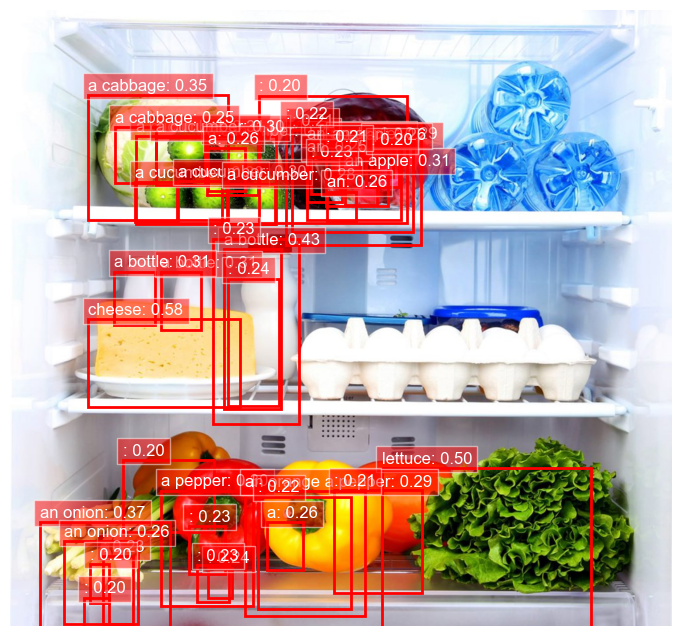

In [67]:
plot_results(image, results)